## Static Env MPPI

In [ ]:
import torch
import time
import sys

# sys.path.append(os.path.dirname(os.path.abspath(os.getcwd())))
sys.path.append("/teamspace/studios/this_studio/PlanarLab")

import ipywidgets as widgets
from IPython.display import display, clear_output
import cv2

from source.simulator.envs.mppi_env import MPPIEnv
from source.controller.mppi import MPPI
from source.tasks.navigation.static_env.static_env_cfg import NavigationStaticMPPIEnvCfg


def convert_to_bytes(image):
    _, buffer = cv2.imencode(".jpg", image)
    return buffer.tobytes()


def main(cfg, save_mode: bool = False):
    device = torch.device(cfg.device)

    # Env
    env = MPPIEnv(cfg)


    # MPPI controller
    solver = MPPI(
        horizon=cfg.horizon,
        num_samples=cfg.num_samples,
        dim_state=cfg.state_dim,
        dim_control=cfg.action_dim,
        dynamics=env.dynamics,
        cost_func=env.cost_function,
        u_min=env.u_min,
        u_max=env.u_max,
        sigmas=cfg.sigmas,
        lambda_=cfg.lambda_,
        auto_lambda=cfg.auto_lambda,
        exploration=cfg.exploration,
        device=device,
    )

    video_widget = widgets.Image(format="jpeg")
    display(video_widget)

    state = env.reset()
    state = torch.as_tensor(state, dtype=torch.float32, device=device).squeeze()

    max_steps = cfg.max_steps
    total_time = 0.0

    for step in range(max_steps):
        start_time = time.time()

        action_seq, state_seq = solver.forward(state=state)

        total_time += (time.time() - start_time)

        action = action_seq[0, :]
        
        current_state = state.detach().clone()
        current_state = current_state.unsqueeze(0).unsqueeze(0)

        # Apply first action from the sequence
        next_state, done, info = env.step(action)

        state = torch.as_tensor(next_state, dtype=torch.float32, device=device).squeeze()

        traj_collision = env.check_trajectory_collision(states=state_seq)

        # Get top sampled trajectories (for visualization/debugging)
        top_samples, top_weights = solver.get_top_samples(num_samples=300)

        frame = env.render(
            state=state,
            action=action,
            predicted_trajectory=state_seq,
            collisions=traj_collision,
            top_samples=(top_samples, top_weights),
        )

        # Convert RGB → BGR (required by OpenCV)
        frame_bgr = cv2.cvtColor(frame[:, :, :3], cv2.COLOR_RGB2BGR)
        video_widget.value = convert_to_bytes(frame_bgr)

        # Refresh display (avoid stacking outputs)
        clear_output(wait=True)
        display(video_widget)

        # Small delay to control playback speed (~100Hz)    
        time.sleep(0.001)

        if done:
            print(f"[INFO] Episode done at step {step}")
            time.sleep(1)
            state = env.reset()
            state = torch.as_tensor(
                state, dtype=torch.float32, device=device
            ).squeeze()
            solver.reset()

    avg_time = total_time / max_steps
    print(f"[INFO] Average solve time: {avg_time * 1000:.3f} ms")

    env.close()


if __name__ == "__main__":
    main(cfg=NavigationStaticMPPIEnvCfg(), save_mode=False)

## Track Environment MPPI

Image(value=b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x02\x01\x0…

KeyboardInterrupt: 

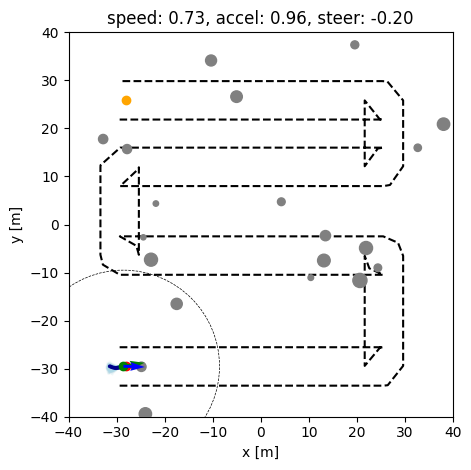

In [1]:
import torch
import time
import sys

# sys.path.append(os.path.dirname(os.path.abspath(os.getcwd())))
sys.path.append("/teamspace/studios/this_studio/PlanarLab")

import ipywidgets as widgets
from IPython.display import display, clear_output
import cv2

from source.simulator.envs.mppi_env import MPPIEnv
from source.controller.mppi import MPPI
from source.tasks.navigation.track_env.track_env_cfg import Navigation2DTrackMPPIEnvCfg


def convert_to_bytes(image):
    _, buffer = cv2.imencode(".jpg", image)
    return buffer.tobytes()


def main(cfg, save_mode: bool = False):
    device = torch.device(cfg.device)

    # Env
    env = MPPIEnv(cfg)


    # MPPI controller
    solver = MPPI(
        horizon=cfg.horizon,
        num_samples=cfg.num_samples,
        dim_state=cfg.state_dim,
        dim_control=cfg.action_dim,
        dynamics=env.dynamics,
        cost_func=env.cost_function,
        u_min=env.u_min,
        u_max=env.u_max,
        sigmas=cfg.sigmas,
        lambda_=cfg.lambda_,
        auto_lambda=cfg.auto_lambda,
        exploration=cfg.exploration,
        device=device,
    )

    video_widget = widgets.Image(format="jpeg")
    display(video_widget)

    state = env.reset()
    state = torch.as_tensor(state, dtype=torch.float32, device=device).squeeze()

    max_steps = cfg.max_steps
    total_time = 0.0

    for step in range(max_steps):
        start_time = time.time()
        action_seq, state_seq = solver.forward(state=state)

        total_time += (time.time() - start_time)

        action = action_seq[0, :]
        
        current_state = state.detach().clone()
        current_state = current_state.unsqueeze(0).unsqueeze(0)

        # Apply first action from the sequence
        next_state, done, info = env.step(action)

        state = torch.as_tensor(next_state, dtype=torch.float32, device=device).squeeze()


        traj_collision = env.check_trajectory_collision(states=state_seq)

        # Get top sampled trajectories (for visualization/debugging)
        top_samples, top_weights = solver.get_top_samples(num_samples=300)

        frame = env.render(
            state=state,
            action=action,
            predicted_trajectory=state_seq,
            collisions=traj_collision,
            top_samples=(top_samples, top_weights),
        )

        # Convert RGB → BGR (required by OpenCV)
        frame_bgr = cv2.cvtColor(frame[:, :, :3], cv2.COLOR_RGB2BGR)
        video_widget.value = convert_to_bytes(frame_bgr)

        # Refresh display (avoid stacking outputs)
        clear_output(wait=True)
        display(video_widget)

        # Small delay to control playback speed (~100Hz)    
        time.sleep(0.001)

        if done:
            print(f"[INFO] Episode done at step {step}")
            time.sleep(1)
            state = env.reset()
            state = torch.as_tensor(
                state, dtype=torch.float32, device=device
            ).squeeze()
            solver.reset()

    avg_time = total_time / max_steps
    print(f"[INFO] Average solve time: {avg_time * 1000:.3f} ms")

    env.close()


if __name__ == "__main__":
    main(cfg=Navigation2DTrackMPPIEnvCfg(), save_mode=False)

## Dynamic Environment MPPI

In [ ]:
import torch
import time
import sys

# sys.path.append(os.path.dirname(os.path.abspath(os.getcwd())))
sys.path.append("/teamspace/studios/this_studio/PlanarLab")

import ipywidgets as widgets
from IPython.display import display, clear_output
import cv2

from source.simulator.envs.mppi_env import MPPIEnv
from source.controller.mppi import MPPI
from source.tasks.navigation.dynamic_env.dynamic_env_cfg import NavigationDynamicMPPIEnvCfg


def convert_to_bytes(image):
    _, buffer = cv2.imencode(".jpg", image)
    return buffer.tobytes()


def main(cfg, save_mode: bool = False):
    device = torch.device(cfg.device)

    # Env
    env = MPPIEnv(cfg)


    # MPPI controller
    solver = MPPI(
        horizon=cfg.horizon,
        num_samples=cfg.num_samples,
        dim_state=cfg.state_dim,
        dim_control=cfg.action_dim,
        dynamics=env.dynamics,
        cost_func=env.cost_function,
        u_min=env.u_min,
        u_max=env.u_max,
        sigmas=cfg.sigmas,
        lambda_=cfg.lambda_,
        auto_lambda=cfg.auto_lambda,
        exploration=cfg.exploration,
        device=device,
    )

    video_widget = widgets.Image(format="jpeg")
    display(video_widget)

    state = env.reset()
    state = torch.as_tensor(state, dtype=torch.float32, device=device).squeeze()

    max_steps = cfg.max_steps
    total_time = 0.0

    for step in range(max_steps):
        start_time = time.time()

        action_seq, state_seq = solver.forward(state=state)

        total_time += (time.time() - start_time)

        action = action_seq[0, :]
        
        current_state = state.detach().clone()
        current_state = current_state.unsqueeze(0).unsqueeze(0)

        # Apply first action from the sequence
        next_state, done, info = env.step(action)

        state = torch.as_tensor(next_state, dtype=torch.float32, device=device).squeeze()

        traj_collision = env.check_trajectory_collision(states=state_seq)

        # Get top sampled trajectories (for visualization/debugging)
        top_samples, top_weights = solver.get_top_samples(num_samples=300)

        frame = env.render(
            state=state,
            action=action,
            predicted_trajectory=state_seq,
            collisions=traj_collision,
            top_samples=(top_samples, top_weights),
        )

        # Convert RGB → BGR (required by OpenCV)
        frame_bgr = cv2.cvtColor(frame[:, :, :3], cv2.COLOR_RGB2BGR)
        video_widget.value = convert_to_bytes(frame_bgr)

        # Refresh display (avoid stacking outputs)
        clear_output(wait=True)
        display(video_widget)

        # Small delay to control playback speed (~100Hz)    
        time.sleep(0.001)

        if done:
            print(f"[INFO] Episode done at step {step}")
            time.sleep(1)
            state = env.reset()
            state = torch.as_tensor(
                state, dtype=torch.float32, device=device
            ).squeeze()
            solver.reset()

    avg_time = total_time / max_steps
    print(f"[INFO] Average solve time: {avg_time * 1000:.3f} ms")

    env.close()


if __name__ == "__main__":
    main(cfg=NavigationDynamicMPPIEnvCfg(), save_mode=False)